## Distribuição Normal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Considere que uma manufatura fabrica barras de aço de 100 mm, com um desvio padrão de 2 mm. Vamos simular a geração de barras com essa distribuição de probabilidade.

In [2]:
# Parâmetros da distribuição
mu = 100     # média (mm)
sigma = 2    # desvio padrão (mm)

# Gerando 1 barra
np.random.normal(mu, sigma)

98.78854027642625

Vamos agora simular a produção de 10 barras.

In [3]:
barras = np.random.normal(mu, sigma, 10)
barras

array([ 99.87596429,  98.66714208, 101.68982865, 101.52365369,
       100.98000512,  99.91562574, 102.3112492 ,  98.307608  ,
       102.02532089, 103.19906242])

Vamos melhorar nosso resultado mostrando 2 casas decimais após o ponto.

In [4]:
np.round(barras, 2)

array([ 99.88,  98.67, 101.69, 101.52, 100.98,  99.92, 102.31,  98.31,
       102.03, 103.2 ])

Vamos agora gerar 1.000 valores de acordo com nossa distribuição normal e plotar um histograma com esses valores.

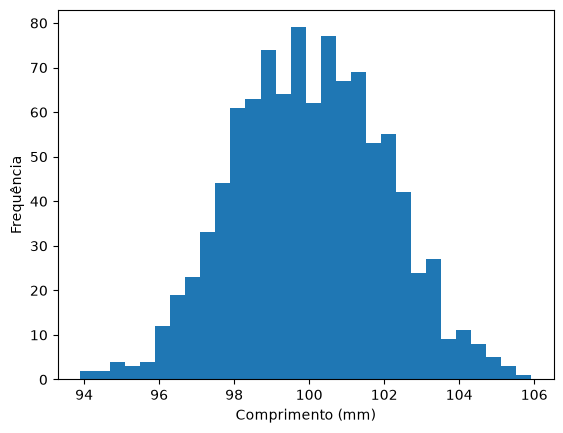

In [5]:
barras = np.random.normal(mu, sigma, 1000)
plt.hist(barras, bins=30)
plt.xlabel('Comprimento (mm)')
plt.ylabel('Frequência')
plt.show()

Vamos aumentar para 1 milhão de valores (simular a produção de 1 milhão de barras).

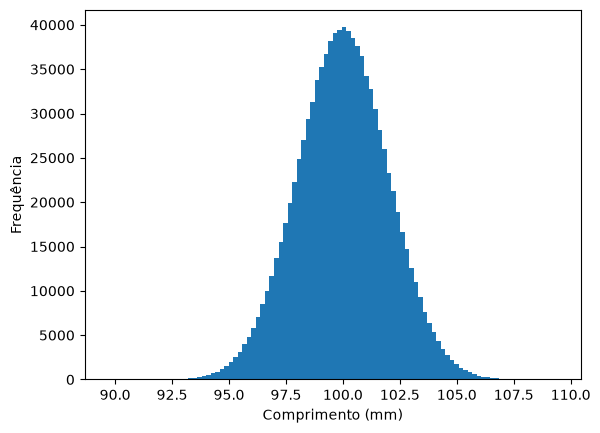

In [6]:
barras = np.random.normal(mu, sigma, 1000000)
plt.hist(barras, bins=100)
plt.xlabel('Comprimento (mm)')
plt.ylabel('Frequência')
plt.show()

Vimos que a área que está entre 1 desvio padrão para mais e para menos corresponde a aproximadamente 68% da área total, 2 desvios padrão, 95%, e 3 desvios padrão, 99,7%. \
Vamos checar esses valores na prática.

In [7]:
# 1 desvio padrão: entre 98 e 102 mm
np.mean((barras > mu - sigma) & (barras < mu + sigma))

np.float64(0.683092)

In [8]:
# 2 desvios padrão: entre 96 e 104 mm
np.mean((barras > mu - 2*sigma) & (barras < mu + 2*sigma))

np.float64(0.954326)

In [9]:
# 3 desvios padrão: entre 94 e 106 mm
np.mean((barras > mu - 3*sigma) & (barras < mu + 3*sigma))

np.float64(0.997159)

Vamos agora usar o pacote stats para realizar cálculos utilizando a distribuição normal.

In [10]:
from scipy.stats import norm

Questão 1 \
Frascos de perfume são preenchidos com um volume médio de 150 ml, com um desvio padrão de 2 ml. Qual a porcentagem de frascos que terão mais de 153 ml?

Funções:
norm.cdf(x, mu, sigma) - Cumulative distribution function - igual ou menos que \
norm.pdf(x, mu, sigma) - Probability density function - para o valor exato \
norm.sf(x, mu, sigma) - Para mais que (similar a 1 - cdf) \
norm.mean(mu) - Para a média da distribuição \
norm.var(mu) - Para a variância da distribuição \
norm.std(mu) - Para o desvio padrão da distribuição

In [11]:
# P(X > 153)
p = norm.sf(153, 150, 2)
print(f'{p * 100:.2f}%')

6.68%


Questão 2 \
Frascos de perfume são preenchidos com um volume médio de 150 ml, com um desvio padrão de 2 ml. Qual a porcentagem de frascos que terão entre 148 e 152 ml de volume?

In [12]:
# P(148 < X < 152)
p = norm.cdf(152, 150, 2) - norm.cdf(148, 150, 2)
print(f'{p * 100:.2f}%')

68.27%


Vamos agora plotar a distribuição normal do nosso exemplo. Para tanto, vamos gerar um vetor que vai de -3 sigma (144) até 3 sigma (156), posteriormente, usaremos a função pmf para obter o valor da probabilidade desses 13 valores.

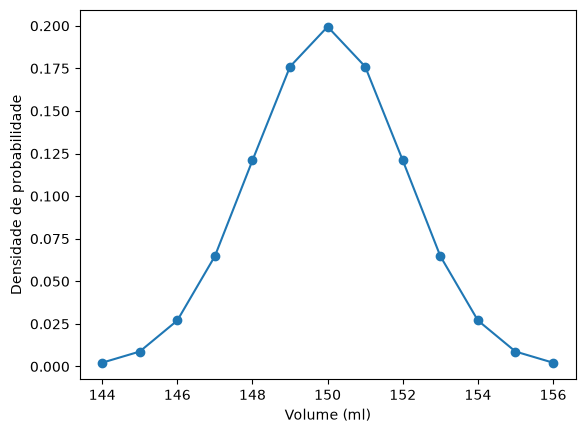

In [13]:
x = np.arange(144, 157)     # 144, 145, ..., 156 (13 valores)
y = norm.pdf(x, 150, 2)
plt.plot(x, y, marker='o')
plt.xlabel('Volume (ml)')
plt.ylabel('Densidade de probabilidade')
plt.show()

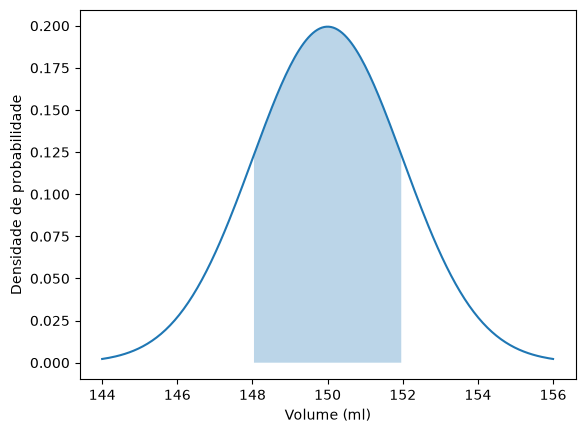

In [14]:
# Curva mais suave usando mais pontos
x = np.linspace(144, 156, 200)
y = norm.pdf(x, 150, 2)
plt.plot(x, y)
plt.fill_between(x, y, where=(x >= 148) & (x <= 152), alpha=0.3)  # área da Questão 2
plt.xlabel('Volume (ml)')
plt.ylabel('Densidade de probabilidade')
plt.show()